# Introduction

In [1]:
from scipy.linalg import svd
import numpy as np
import random
import matplotlib.pyplot as plt

# Problem 1

In [3]:
def squared_error(A, B):
    """
    Compute the element-wise squared error between matrices A and B.

    Parameters:
    - A, B: numpy arrays
        Matrices for which squared error is calculated. A and B must have the same shape.

    Returns:
    - numpy array
        Element-wise squared error between A and B.
    """
    square_error = np.square(A - B)
    
    return square_error

def get_SVD(A):
    '''
    Compute the Single-Value Decomposition of a matrix, A.
    Parameters:
    A - (numpy array) matrix for which Single-Value Decomposition is to be perfomed.
    Returns:
    U - (numpy array) with left singular vectors.
    S - (numpy array) containing the Eigenvalues as a matrix.
    V - (numpy array) with right singular vectors.
    '''
    from scipy.linalg import svd
    import numpy as np
    W = np.dot(A,A.T)
    # find U
    eigenvalues, U = np.linalg.eig(W)
    eigenvalues = np.sqrt(eigenvalues)

    # Find V
    W = np.dot(A.T,A)
    _, V = np.linalg.eig(W)
    
    # find Eigenvalue matrix, S
    S = np.diag(eigenvalues)
    
    # locate the zero eigenvalue indeces
    non_zero_diagonal_columns = np.any(np.diag(eigenvalues) != 0, axis=0)
    
    # Remove those columns from S
    S = S[:, non_zero_diagonal_columns]
    
    # Append S with 'zero' rows to get correct dimensions
    num_columns_remove = abs(V.T.shape[0] - S.shape[1])
    # Remove n columns from the matrix
    if num_columns_remove != 0:
        S =  np.delete(S, np.s_[-num_columns_remove:], axis=1)
    U, _, V, = svd(A)
    return U, S, V

def SVD_2_matrix(U,S,V):

    '''
    Takes Single value Decomposition and returns the matrix
    Parameters:
    U - (numpy array) with left singular vectors
    S - (numpy array) containing the Eigenvalues as a matrix
    V - (numpy array) with right singular vectors
    
    Returns:
    A- (numpy array) containing composed matrix   
    
    '''
    A = np.dot(U,S)
    A = np.dot(A, V.T)

    return A


# Example with 2 x 4 matrix
A = np.array([[2,  4],
              [1,  3],
              [0,  0],
              [0,  0]])


U, S, V = get_SVD(A)
if S.shape == A.shape:
    print('Test 1 passed.')
else:
    print('Test 1 failed.')
A_check = SVD_2_matrix(U,S,V)
if A_check.all() == A.all():
    print('Test 2 passed.')


Test 1 passed.
Test 2 passed.


In [4]:
# Example with 2 x 4 matrix
A = np.loadtxt("A.csv",delimiter=",")

U, S, V = get_SVD(A)
if S.shape == A.shape:
    print('Test 1 passed.')
else:
    print('Test 1 failed.')
A_check = SVD_2_matrix(U,S,V.T)
if A_check.all() == A.all():
    print('Test 2 passed.')
else:
    print('Test 2 failed.')

Test 1 passed.
Test 2 passed.


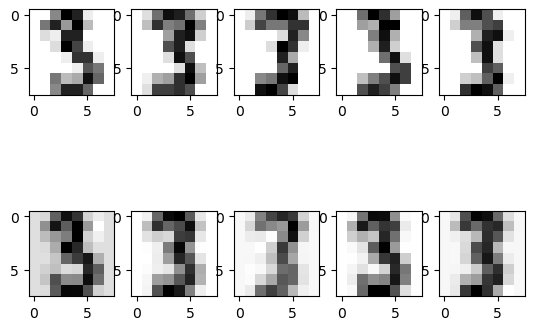

In [4]:
import numpy as np


def get_SVD(A):
    '''
    Compute the Single-Value Decomposition of a matrix, A.
    Parameters:
    A - (numpy array) matrix for which Single-Value Decomposition is to be perfomed.
    Returns:
    U - (numpy array) with left singular vectors.
    S - (numpy array) containing the Eigenvalues as a matrix.
    V - (numpy array) with right singular vectors.
    '''
    from scipy.linalg import svd
    import numpy as np
    W = np.dot(A,A.T)
    # find U
    eigenvalues, U = np.linalg.eig(W)
    eigenvalues = np.sqrt(eigenvalues)

    # Find V
    W = np.dot(A.T,A)
    _, V = np.linalg.eig(W)
    
    # find Eigenvalue matrix, S
    S = np.diag(eigenvalues)
    
    # locate the zero eigenvalue indeces
    non_zero_diagonal_columns = np.any(np.diag(eigenvalues) != 0, axis=0)
    
    # Remove those columns from S
    S = S[:, non_zero_diagonal_columns]
    
    # Append S with 'zero' rows to get correct dimensions
    num_columns_remove = abs(V.T.shape[0] - S.shape[1])
    # Remove n columns from the matrix
    if num_columns_remove != 0:
        S =  np.delete(S, np.s_[-num_columns_remove:], axis=1)
    U, _, V, = svd(A)
    return U, S, V

def SVD_2_matrix(U,S,V):

    '''
    Takes Single value Decomposition and returns the matrix
    Parameters:
    U - (numpy array) with left singular vectors
    S - (numpy array) containing the Eigenvalues as a matrix
    V - (numpy array) with right singular vectors
    
    Returns:
    A- (numpy array) containing composed matrix   
    
    '''
    A = np.dot(U,S)
    A = np.dot(A, V.T)

    return A

def squared_error(A, B):
    """
    Compute the element-wise squared error between matrices A and B.

    Parameters:
    - A, B: numpy arrays
        Matrices for which squared error is calculated. A and B must have the same shape.

    Returns:
    - numpy array
        Element-wise squared error between A and B.
    """
    square_error = np.square(A - B)
    
    return square_error

# This matrix A contains 183 8x8 images of the handwritten digit 3. 
# Each image has been reshaped into a length 64 row vector.
A = np.loadtxt("A.csv",delimiter=",")

# TODO: perform SVD on A, zero out all but the top 3 singular values to obtain a
# new matrix B and compute ||A-B||^2
U1, eigenvalues, V1 = np.linalg.svd(A)
desired_num_eigenvals = 3
eig_val_top = eigenvalues[:desired_num_eigenvals]

# print('The top three singular values are ', np.real(eig_val_top_three))

# Append eigenvalues with zeros to meet dimensions
eigs_B = np.concatenate((eig_val_top, np.zeros(np.shape(A)[1]-eig_val_top.size)))

    

# Use np.diag to place eigenvalues and corresponding zeros along diagonal
S_new = np.diag(eigs_B)

# append S_new with rows of '0'
desired_num_rows = abs(A.shape[1] - A.shape[0])
S_new = np.vstack([S_new, np.zeros((desired_num_rows,S_new.shape[1]))])



desired_dimensions  = A.shape
# Get S, V matrices
U, _, V = get_SVD(A)

# Calculate B matrix using alternative SVD matrices 
B = SVD_2_matrix(U,S_new,V.T)


# filter out imaginary parts (all are equal to zero)
B = np.real(B)
    
# Find the sum squared difference between A, B
square_error = squared_error(A, B)

# OPTIONAL: You don't need to turn in the output from the code below.
# But if you're curious to see the result of this modification to
# the data using only three singular values, this code snippet will plot
# each handwritten 3 BEFORE (on the top) and AFTER (on the bottom)
# the modification.

# reconstruct A via SVD to check results are correct
A = np.loadtxt("A.csv",delimiter=",")


U, S, V = get_SVD(A)
A_check = SVD_2_matrix(U,S,V.T)


# reconstruct
A_reconstruct = SVD_2_matrix(U,S,V.T)


from matplotlib import pyplot as plt

# How many rows and cols in our figure?
NUM_IMGS_TO_SHOW = 5
NUM_PLOT_ROWS = 2
NUM_PLOT_COLS = NUM_IMGS_TO_SHOW


for ind in range(NUM_IMGS_TO_SHOW):

    # The data before and after
    before_vec = A[ind,:]
    after_vec = B[ind,:]
    reconstruct_vec = A_reconstruct[ind,:]

    # We reshape the date into an 8x8 grid
    before_img = np.reshape(before_vec, [8,8])
    after_img = np.reshape(after_vec, [8,8])
    reconstruct_img = np.reshape(reconstruct_vec, [8, 8])

    # Now let's plot the before an after into two rows:
    plt.subplot(NUM_PLOT_ROWS,NUM_PLOT_COLS,ind+1)
    plt.imshow(before_img, cmap=plt.cm.gray_r, interpolation='nearest')

    # Plot reconstructed A matrix
    # plt.subplot(NUM_PLOT_ROWS,NUM_PLOT_COLS,ind + NUM_IMGS_TO_SHOW + 1)
    # plt.imshow(reconstruct_img, cmap=plt.cm.gray_r, interpolation='nearest')

    # Plot B ('after') matrix
    plt.subplot(NUM_PLOT_ROWS,NUM_PLOT_COLS,ind +  NUM_IMGS_TO_SHOW + 1)
    plt.imshow(after_img, cmap=plt.cm.gray_r, interpolation='nearest')

plt.show()


# Problem 4

The value of λ is:  3.9908


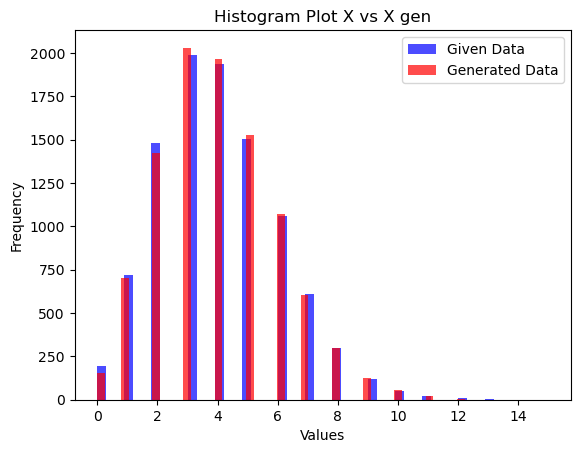

In [5]:
# Part 2.
X = np.loadtxt("X.csv",delimiter=",")
lambda_hat = np.mean(X)
print('The value of λ is: ', lambda_hat)

# Part 3.
X_gen = []
for i in range(10000):
    x_gen = np.random.poisson(lambda_hat)
    X_gen.append(x_gen)
    
    
# Plotting the histogram
plt.hist(X, bins=50, color='blue', alpha=0.7, label = 'Given Data')
plt.hist(X_gen, bins=50, color='red', alpha=0.7, label = 'Generated Data')
plt.title('Histogram Plot X vs X gen')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()

# Show the plot
plt.show()